In [1]:
# Problema: Decidir qué productos incluir en un catálogo limitado, sabiendo que la demanda de cada producto depende de cuáles otros se ofrecen junto a él.

from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from IPython.display import display
from IPython import get_ipython

data_dir = Path("../data")
submission_dir = Path("../submission")
get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
display(["products.csv"])

['products.csv']

In [2]:
# Catalogo sintetico de una sola categoria; no representa un catalogo real.

products = pd.read_csv(data_dir / "products.csv")
products["unit_margin"] = products.price - products.unit_cost
display(products)

,product_id,price,unit_cost,attractiveness,unit_margin
0,P1,75,35,1.60,40
1,P2,60,28,1.30,32
2,P3,55,26,1.10,29
3,P4,42,22,0.55,20
4,P5,35,19,0.50,16
5,P6,25,13,2.60,12
6,P7,20,11,2.20,9
7,P8,20,14,0.35,6


In [3]:
# Verificamos que el catalogo este bien definido antes de decidir nada.

assert len(products) == 8 and products.product_id.is_unique
assert (products.price > products.unit_cost).all()
assert (products.unit_margin > 0).all()
assert (products.attractiveness > 0).all()
print(f"{len(products)} productos candidatos; todos con margen positivo y atractivo positivo.")

8 productos candidatos; todos con margen positivo y atractivo positivo.


In [4]:
# Parametros base del modelo de eleccion: atractivo de no comprar y tamano maximo del catalogo.

no_purchase_attractiveness = 1.0
max_products = 4
assert no_purchase_attractiveness > 0 and max_products > 0
v = products.set_index("product_id").attractiveness.to_dict()
margin = products.set_index("product_id").unit_margin.to_dict()
product_ids = products.product_id.tolist()
print(f"v0 = {no_purchase_attractiveness}; K = {max_products}.")

v0 = 1.0; K = 4.


In [5]:
# Funciones deterministas del modelo de eleccion tipo logit multinomial.

def choice_probabilities(S, v0=no_purchase_attractiveness):
    if not S:
        return {}
    denom = v0 + sum(v[i] for i in S)
    return {i: v[i] / denom for i in S}

def no_purchase_probability(S, v0=no_purchase_attractiveness):
    if not S:
        return 1.0
    denom = v0 + sum(v[i] for i in S)
    return v0 / denom

def purchase_probability(S, v0=no_purchase_attractiveness):
    return 1.0 - no_purchase_probability(S, v0)

def expected_margin(S, v0=no_purchase_attractiveness):
    if not S:
        return 0.0
    p = choice_probabilities(S, v0)
    return sum(p[i] * margin[i] for i in S)

print("Funciones de eleccion definidas: probabilidades, no-compra y margen esperado.")

Funciones de eleccion definidas: probabilidades, no-compra y margen esperado.


In [6]:
# Ejemplo ilustrativo: el surtido {P1, P2} antes de cualquier optimizacion.

example_S = ("P1", "P2")
example_p = choice_probabilities(example_S)
example_p0 = no_purchase_probability(example_S)
example_denom = no_purchase_attractiveness + sum(v[i] for i in example_S)
print(f"Denominador: {example_denom}")
print(f"P(P1|S) = {example_p['P1']:.3f}")
print(f"P(P2|S) = {example_p['P2']:.3f}")
print(f"P(no compra|S) = {example_p0:.3f}")
print(f"Suma de probabilidades: {sum(example_p.values()) + example_p0:.3f}")
print(f"Margen esperado por cliente: {expected_margin(example_S):.3f}")

Denominador: 3.9000000000000004
P(P1|S) = 0.410
P(P2|S) = 0.333
P(no compra|S) = 0.256
Suma de probabilidades: 1.000
Margen esperado por cliente: 27.077


In [7]:
# La economia de cada producto por separado ignora la canibalizacion.

standalone_rows = []
for i in product_ids:
    p_i = choice_probabilities((i,))[i]
    r_i = expected_margin((i,))
    standalone_rows.append((i, margin[i], v[i], p_i, r_i))
standalone = pd.DataFrame(
    standalone_rows,
    columns=[
        "product_id", "unit_margin", "attractiveness",
        "standalone_purchase_probability", "standalone_expected_margin",
    ],
).sort_values("standalone_expected_margin", ascending=False).reset_index(drop=True)
display(standalone)

,product_id,unit_margin,attractiveness,standalone_purchase_probability,standalone_expected_margin
0,P1,40,1.60,0.615385,24.615385
1,P2,32,1.30,0.565217,18.086957
2,P3,29,1.10,0.523810,15.190476
3,P6,12,2.60,0.722222,8.666667
4,P4,20,0.55,0.354839,7.096774
5,P7,9,2.20,0.687500,6.187500
6,P5,16,0.50,0.333333,5.333333
7,P8,6,0.35,0.259259,1.555556


In [8]:
# Politica A: los cuatro productos con mayor margen unitario.

policy_margin = tuple(products.sort_values("unit_margin", ascending=False).head(max_products).product_id)
policy_margin_value = expected_margin(policy_margin)
print(f"Politica de mayor margen: {policy_margin}; margen esperado = {policy_margin_value:.3f}")

Politica de mayor margen: ('P1', 'P2', 'P3', 'P4'); margen esperado = 26.757


In [9]:
# Politica B: los cuatro productos mas atractivos para el cliente.

policy_attractiveness = tuple(products.sort_values("attractiveness", ascending=False).head(max_products).product_id)
policy_attractiveness_value = expected_margin(policy_attractiveness)
print(f"Politica de mayor atractivo: {policy_attractiveness}; margen esperado = {policy_attractiveness_value:.3f}")

Politica de mayor atractivo: ('P6', 'P7', 'P1', 'P2'); margen esperado = 18.000


In [10]:
# Politica C: los cuatro productos con mayor margen esperado individual.

policy_standalone = tuple(standalone.head(max_products).product_id)
policy_standalone_value = expected_margin(policy_standalone)
print(f"Politica de mayor margen individual: {policy_standalone}; margen esperado = {policy_standalone_value:.3f}")

Politica de mayor margen individual: ('P1', 'P2', 'P3', 'P6'); margen esperado = 22.197


In [11]:
# DECISION MODEL
# ---------------------------------------------------------------------
# Set:
#   i in PRODUCTS
#
# Parameters:
#   v[i]        product attractiveness
#   margin[i]   contribution margin
#   v0          no-purchase attractiveness
#   K           maximum number of products
#
# Decision:
#   choose assortment S subset of PRODUCTS
#
# Choice probability:
#   P(i | S)
#       = v[i] /
#         (v0 + sum{j in S} v[j])
#
# Expected contribution margin:
#   R(S)
#       = sum{i in S}
#           P(i | S) * margin[i]
#
# Objective:
#   maximize R(S)
#
# Constraint:
#   |S| <= K

display(pd.Series({"products": len(product_ids), "max_products": max_products}))

products        8
max_products    4
dtype: int64

In [12]:
# Un MILP aditivo asignaria a cada producto un valor fijo, pero P(i|S) depende de todo el surtido.

print("maximize sum_i standalone_value[i] * x[i]  -- seria incorrecto en este modelo.")
print("P(i|S) depende del conjunto completo S, no solo de si el producto i esta incluido.")
print("Un mismo producto no tiene un valor de contribucion fijo independiente de los demas.")
print("A esta escala, la busqueda exhaustiva es el metodo transparente correcto; no se requiere PuLP ni HiGHS.")

maximize sum_i standalone_value[i] * x[i]  -- seria incorrecto en este modelo.
P(i|S) depende del conjunto completo S, no solo de si el producto i esta incluido.
Un mismo producto no tiene un valor de contribucion fijo independiente de los demas.
A esta escala, la busqueda exhaustiva es el metodo transparente correcto; no se requiere PuLP ni HiGHS.


In [13]:
# Enumeramos cada surtido factible con hasta K productos, incluyendo el vacio.

def canonical(S):
    return "|".join(sorted(S)) if S else "EMPTY"

assortment_rows = []
for k in range(0, max_products + 1):
    for combo in combinations(product_ids, k):
        n = len(combo)
        pur = purchase_probability(combo)
        nopur = no_purchase_probability(combo)
        r = expected_margin(combo)
        assortment_rows.append((canonical(combo), n, pur, nopur, r))
assortment_results = pd.DataFrame(
    assortment_rows,
    columns=[
        "assortment", "n_products", "purchase_probability",
        "no_purchase_probability", "expected_margin_per_customer",
    ],
)
expected_count = sum(len(list(combinations(product_ids, k))) for k in range(0, max_products + 1))
assert len(assortment_results) == expected_count == 163
assert assortment_results.assortment.is_unique
print(f"{len(assortment_results)} surtidos factibles evaluados (incluyendo el vacio).")

163 surtidos factibles evaluados (incluyendo el vacio).


In [14]:
# Clasificamos los surtidos de forma determinista: margen esperado, con desempate estable.

assortment_results = assortment_results.sort_values(
    ["expected_margin_per_customer", "assortment"], ascending=[False, True]
).reset_index(drop=True)
assortment_results["rank"] = assortment_results.index + 1
display(assortment_results.head(5))

optimal_row = assortment_results.iloc[0]
optimal_assortment = tuple(optimal_row.assortment.split("|"))
optimal_value = optimal_row.expected_margin_per_customer
print(f"Optimo: {optimal_assortment}; n={len(optimal_assortment)}; R={optimal_value:.3f}; capacidad K={max_products}.")

,assortment,n_products,purchase_probability,no_purchase_probability,expected_margin_per_customer,rank
0,P1|P2|P3,3,0.800000,0.200000,27.500000,1
1,P1|P2,2,0.743590,0.256410,27.076923,2
2,P1|P2|P3|P4,4,0.819820,0.180180,26.756757,3
3,P1|P2|P3|P5,4,0.818182,0.181818,26.454545,4
4,P1|P2|P4,3,0.775281,0.224719,26.202247,5


Optimo: ('P1', 'P2', 'P3'); n=3; R=27.500; capacidad K=4.


In [15]:
# La unicidad separa una recomendacion concreta de alternativas empatadas.

optimal_count = int(np.isclose(assortment_results.expected_margin_per_customer, optimal_value).sum())
second_row = assortment_results.iloc[1]
second_assortment = tuple(second_row.assortment.split("|"))
second_value = second_row.expected_margin_per_customer
gap = optimal_value - second_value
print(f"Optimos encontrados: {optimal_count}")
print(f"Segundo mejor: {second_assortment}; R={second_value:.3f}; brecha={gap:.3f}")

Optimos encontrados: 1
Segundo mejor: ('P1', 'P2'); R=27.077; brecha=0.423


In [16]:
# El surtido optimo domina a las tres politicas ingenuas bajo el mismo criterio.

policy_comparison = pd.DataFrame(
    [
        ["highest_unit_margin", policy_margin, policy_margin_value],
        ["highest_attractiveness", policy_attractiveness, policy_attractiveness_value],
        ["highest_standalone_value", policy_standalone, policy_standalone_value],
        ["optimized", optimal_assortment, optimal_value],
    ],
    columns=["policy", "assortment", "expected_margin_per_customer"],
)
policy_comparison["gap_vs_optimized"] = policy_comparison.expected_margin_per_customer - optimal_value
display(policy_comparison)

,policy,assortment,expected_margin_per_customer,gap_vs_optimized
0,highest_unit_margin,"(P1, P2, P3, P4)",26.756757,-0.743243
1,highest_attractiveness,"(P6, P7, P1, P2)",18.000000,-9.500000
2,highest_standalone_value,"(P1, P2, P3, P6)",22.197368,-5.302632
3,optimized,"(P1, P2, P3)",27.500000,0.000000


In [17]:
# Partimos de un surtido fuerte y agregamos un producto aparentemente rentable.

strong_S = ("P1", "P2", "P3")
candidate = "P4"
after_S = strong_S + (candidate,)

before_p = choice_probabilities(strong_S)
before_p0 = no_purchase_probability(strong_S)
before_R = expected_margin(strong_S)

after_p = choice_probabilities(after_S)
after_p0 = no_purchase_probability(after_S)
after_R = expected_margin(after_S)

comparison = pd.DataFrame(
    {
        "antes": [before_p["P1"], before_p["P2"], before_p["P3"], None, before_p0],
        "despues": [after_p["P1"], after_p["P2"], after_p["P3"], after_p[candidate], after_p0],
    },
    index=["P1", "P2", "P3", candidate, "no_compra"],
)
display(comparison)
print(f"R(S) antes de agregar {candidate}: {before_R:.3f}")
print(f"R(S) despues de agregar {candidate}: {after_R:.3f}")
print(f"Cambio en el margen esperado: {after_R - before_R:+.3f}")
print(f"{candidate} recibe demanda positiva, pero reduce el margen total del surtido.")

,antes,despues
P1,0.32,0.288288
P2,0.26,0.234234
P3,0.22,0.198198
P4,NaN,0.099099
no_compra,0.20,0.180180


R(S) antes de agregar P4: 27.500
R(S) despues de agregar P4: 26.757
Cambio en el margen esperado: -0.743
P4 recibe demanda positiva, pero reduce el margen total del surtido.


In [18]:
# Condicion analitica: agregar k mejora R(S) si y solo si margin[k] > R(S).

print(f"margin[{candidate}] = {margin[candidate]}")
print(f"R(S) = {before_R:.3f}")
condition_holds = margin[candidate] > before_R
print(f"{margin[candidate]} > {before_R:.3f}? {condition_holds}")
print("La condicion predice una reduccion; la recomputacion directa ya lo confirmo.")
assert not condition_holds
assert after_R < before_R

margin[P4] = 20
R(S) = 27.500
20 > 27.500? False
La condicion predice una reduccion; la recomputacion directa ya lo confirmo.


In [19]:
# El mismo producto, el mismo precio, el mismo costo: su valor marginal depende del contexto.

weak_S = ("P6",)
delta_weak = expected_margin(weak_S + (candidate,)) - expected_margin(weak_S)
delta_strong = after_R - before_R
print(f"Delta_{candidate}(surtido debil {weak_S}) = {delta_weak:+.3f}")
print(f"Delta_{candidate}(surtido fuerte {strong_S}) = {delta_strong:+.3f}")
print("El valor marginal de un producto no es una propiedad fija: depende del surtido que lo rodea.")

Delta_P4(surtido debil ('P6',)) = +1.502
Delta_P4(surtido fuerte ('P1', 'P2', 'P3')) = -0.743
El valor marginal de un producto no es una propiedad fija: depende del surtido que lo rodea.


In [20]:
# Validamos el caso completo de forma independiente antes de la sensibilidad y el tablero.

for S_check in [strong_S, after_S, weak_S, policy_margin, policy_attractiveness, policy_standalone]:
    p_check = choice_probabilities(S_check)
    p0_check = no_purchase_probability(S_check)
    assert all(0 <= val <= 1 for val in p_check.values())
    assert 0 <= p0_check <= 1
    assert np.isclose(sum(p_check.values()) + p0_check, 1.0)
    assert len(S_check) <= max_products

assert len(assortment_results) == 163
assert assortment_results.assortment.is_unique
assert set(optimal_assortment).issubset(set(product_ids))
assert optimal_assortment in [tuple(a.split("|")) for a in assortment_results.assortment]
assert np.isclose(expected_margin(optimal_assortment), optimal_value)
assert optimal_value > second_value
assert optimal_value >= policy_margin_value
assert optimal_value >= policy_attractiveness_value
assert optimal_value >= policy_standalone_value
assert len(optimal_assortment) == 3
assert standalone.loc[standalone.product_id == candidate, "standalone_expected_margin"].iloc[0] > 0
assert after_R < before_R
assert delta_weak > 0
print("Validado: probabilidades, enumeracion, optimo y ejemplos de canibalizacion son consistentes.")

Validado: probabilidades, enumeracion, optimo y ejemplos de canibalizacion son consistentes.


In [21]:
# Resolvemos el mismo problema para distintos limites de capacidad del catalogo.

def best_assortment_for_capacity(k_cap):
    best_r, best_S = -1.0, ()
    for k in range(0, k_cap + 1):
        for combo in combinations(product_ids, k):
            r = expected_margin(combo)
            if r > best_r:
                best_r, best_S = r, combo
    return best_S, best_r

capacity_rows = []
for k_cap in range(1, 7):
    best_S, best_r = best_assortment_for_capacity(k_cap)
    capacity_rows.append((k_cap, canonical(best_S), len(best_S), best_r, purchase_probability(best_S)))
capacity_sensitivity = pd.DataFrame(
    capacity_rows,
    columns=[
        "max_products", "optimal_assortment", "n_selected",
        "expected_margin_per_customer", "purchase_probability",
    ],
)
display(capacity_sensitivity)

,max_products,optimal_assortment,n_selected,expected_margin_per_customer,purchase_probability
0,1,P1,1,24.615385,0.615385
1,2,P1|P2,2,27.076923,0.743590
2,3,P1|P2|P3,3,27.500000,0.800000
3,4,P1|P2|P3,3,27.500000,0.800000
4,5,P1|P2|P3,3,27.500000,0.800000
5,6,P1|P2|P3,3,27.500000,0.800000


In [22]:
# La capacidad adicional deja de tener valor economico optimo despues de K=3.

assert (capacity_sensitivity.loc[capacity_sensitivity.max_products >= 3, "n_selected"] == 3).all()
plateau_values = capacity_sensitivity.loc[capacity_sensitivity.max_products >= 3, "expected_margin_per_customer"]
assert np.allclose(plateau_values, optimal_value)
print("A partir de K=3, el optimizador deja de usar las plazas adicionales: no es que agregar productos no tenga efecto,")
print("es que el optimizador elige no usarlas porque ningun producto adicional mejora el margen esperado.")

A partir de K=3, el optimizador deja de usar las plazas adicionales: no es que agregar productos no tenga efecto,
es que el optimizador elige no usarlas porque ningun producto adicional mejora el margen esperado.


In [23]:
# Sensibilidad compacta y solo de cuaderno: como cambia el surtido optimo si el cliente es mas reacio a comprar.

def best_assortment_for_v0(v0_value, k_cap=max_products):
    best_r, best_S = -1.0, ()
    for k in range(0, k_cap + 1):
        for combo in combinations(product_ids, k):
            r = expected_margin(combo, v0=v0_value)
            if r > best_r:
                best_r, best_S = r, combo
    return best_S, best_r

for v0_value in [0.5, 1.0, 2.0, 4.0]:
    best_S, best_r = best_assortment_for_v0(v0_value)
    print(f"v0={v0_value}: optimo={canonical(best_S)}; R={best_r:.3f}")

v0=0.5: optimo=P1|P2; R=31.059
v0=1.0: optimo=P1|P2|P3; R=27.500
v0=2.0: optimo=P1|P2|P3; R=22.917
v0=4.0: optimo=P1|P2|P3|P4; R=17.368


In [24]:
# Registramos la decision final por producto: seleccion y probabilidad de eleccion en el optimo.

optimal_p = choice_probabilities(optimal_assortment)
product_decisions = standalone.merge(products[["product_id", "price", "unit_cost"]], on="product_id")
product_decisions["selected_optimal"] = product_decisions.product_id.isin(optimal_assortment).astype(int)
product_decisions["choice_probability_optimal"] = product_decisions.product_id.map(optimal_p).fillna(0.0)
product_decisions = product_decisions[
    [
        "product_id", "price", "unit_cost", "unit_margin", "attractiveness",
        "standalone_expected_margin", "selected_optimal", "choice_probability_optimal",
    ]
]
display(product_decisions)

,product_id,price,unit_cost,unit_margin,attractiveness,standalone_expected_margin,selected_optimal,choice_probability_optimal
0,P1,75,35,40,1.60,24.615385,1,0.32
1,P2,60,28,32,1.30,18.086957,1,0.26
2,P3,55,26,29,1.10,15.190476,1,0.22
3,P6,25,13,12,2.60,8.666667,0,0.00
4,P4,42,22,20,0.55,7.096774,0,0.00
5,P7,20,11,9,2.20,6.187500,0,0.00
6,P5,35,19,16,0.50,5.333333,0,0.00
7,P8,20,14,6,0.35,1.555556,0,0.00


In [25]:
# Construimos el planeador sin mostrarlo hasta completar los cuatro paneles.

planner = Figure(figsize=(13, 9), layout="constrained")
grid = planner.add_gridspec(2, 2)
ax_econ = planner.add_subplot(grid[0, 0])
ax_choice = planner.add_subplot(grid[0, 1])
ax_policy = planner.add_subplot(grid[1, 0])
ax_capacity = planner.add_subplot(grid[1, 1])

colors = ["#287d78" if pid in optimal_assortment else "#8299ad" for pid in products.product_id]
ax_econ.scatter(products.attractiveness, products.unit_margin, s=90, c=colors, edgecolor="black")
for row in products.itertuples():
    if row.product_id in ("P1", "P2", "P3", "P4", "P6"):
        ax_econ.annotate(
            row.product_id, (row.attractiveness, row.unit_margin),
            xytext=(6, 6), textcoords="offset points", fontsize=9,
        )
ax_econ.set(xlabel="Atractivo", ylabel="Margen unitario", title="Economia de cada producto; verde = surtido optimo");

In [26]:
# Panel 2: probabilidades de eleccion del surtido optimo, incluida la no-compra.

choice_labels = list(optimal_assortment) + ["No compra"]
choice_values = [optimal_p[i] for i in optimal_assortment] + [no_purchase_probability(optimal_assortment)]
ax_choice.bar(choice_labels, choice_values, color=["#287d78"] * len(optimal_assortment) + ["#b64d39"])
ax_choice.set(ylabel="Probabilidad", title="Eleccion del cliente bajo el surtido optimo")

policy_bar_labels = ["Mayor margen", "Mayor atractivo", "Mayor individual", "Optimizado"]
bars = ax_policy.bar(
    policy_bar_labels, policy_comparison.expected_margin_per_customer,
    color=["#b48b47", "#8299ad", "#608b9a", "#287d78"],
)
ax_policy.bar_label(bars, fmt="%.1f", padding=3)
ax_policy.set(
    ylabel="Margen esperado por cliente", title="El surtido optimizado supera a las politicas ingenuas"
)

ax_capacity.plot(
    capacity_sensitivity.max_products, capacity_sensitivity.expected_margin_per_customer,
    marker="o", color="#287d78",
)
for row in capacity_sensitivity.itertuples():
    ax_capacity.annotate(
        f"n={row.n_selected}", (row.max_products, row.expected_margin_per_customer),
        xytext=(0, 8), textcoords="offset points", fontsize=8, ha="center",
    )
ax_capacity.set(
    xlabel="Capacidad K", ylabel="Margen esperado por cliente",
    title="Mas capacidad no siempre se usa por completo",
);

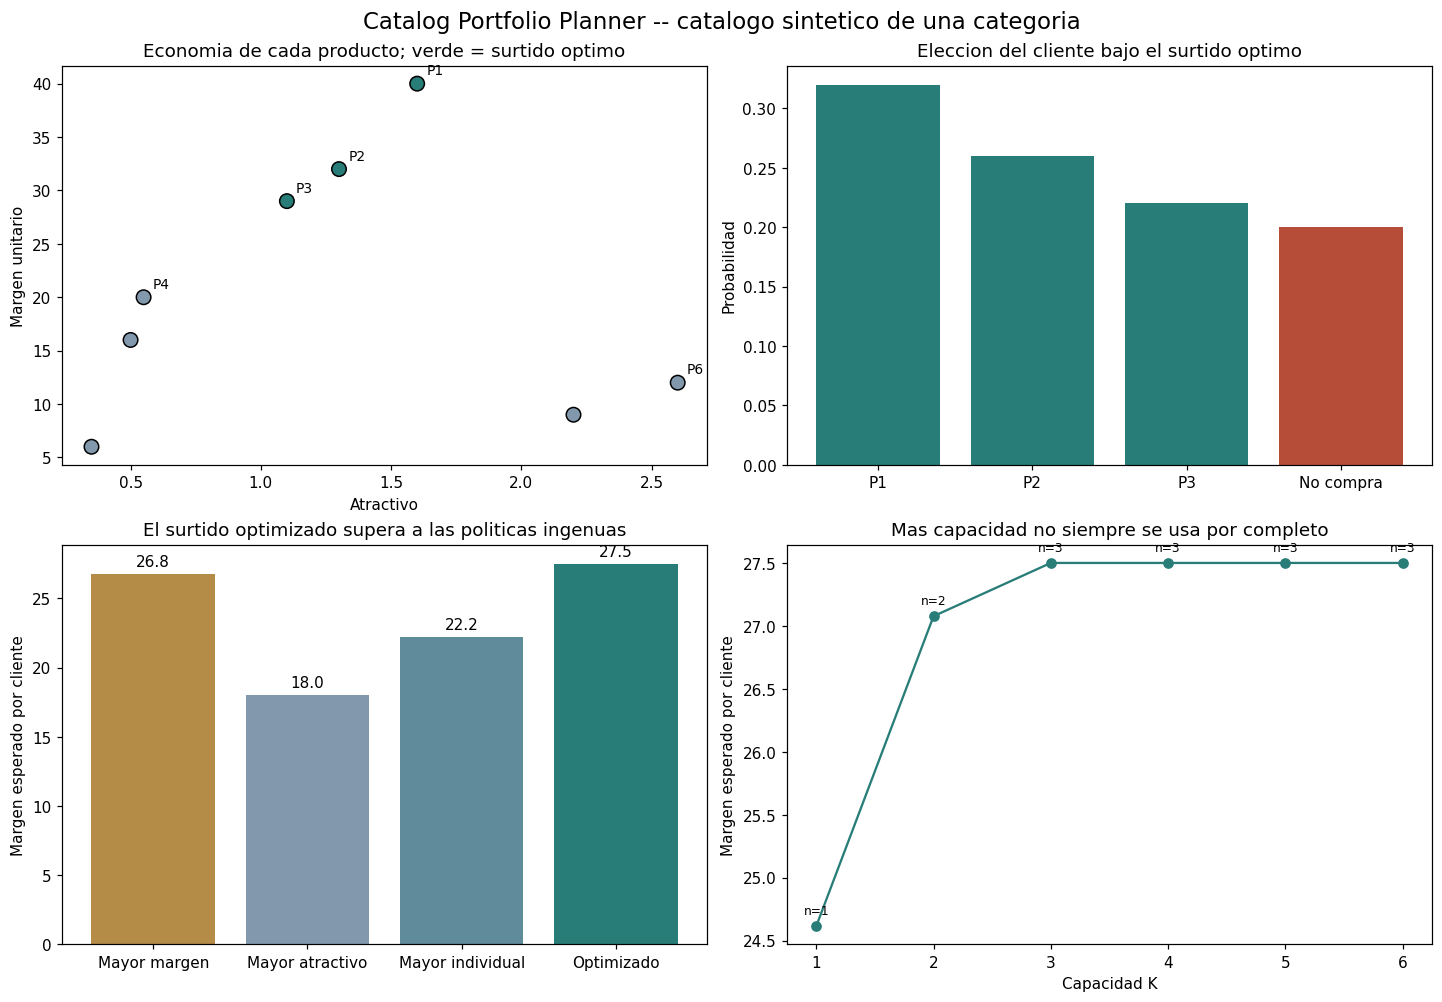

In [27]:
# El planeador completo es el producto de decision: que ofrecer y por que.

planner.suptitle("Catalog Portfolio Planner -- catalogo sintetico de una categoria", fontsize=15)
display(planner)

In [28]:
# Verificamos el caso completo antes de generar los artefactos de entrega.

assert len(products) == 8
assert (products.unit_margin > 0).all()
assert no_purchase_attractiveness == 1.0 and max_products == 4
assert len(assortment_results) == 163
assert optimal_count == 1
assert optimal_assortment == ("P1", "P2", "P3")
assert len(optimal_assortment) == 3
assert np.isclose(optimal_value, 27.5, atol=0.01)
assert np.isclose(purchase_probability(optimal_assortment), 0.8, atol=0.01)
assert second_assortment == ("P1", "P2")
assert np.isclose(gap, 0.423, atol=0.01)
assert policy_margin_value < optimal_value
assert policy_attractiveness_value < optimal_value
assert policy_standalone_value < optimal_value
assert np.isclose(after_R - before_R, -0.743, atol=0.01)
assert np.isclose(delta_weak, 1.502, atol=0.01)
assert (capacity_sensitivity.loc[capacity_sensitivity.max_products >= 3, "n_selected"] == 3).all()
print("Verificado: enumeracion, optimo, canibalizacion, no aditividad y sensibilidad de capacidad consistentes.")

Verificado: enumeracion, optimo, canibalizacion, no aditividad y sensibilidad de capacidad consistentes.


In [29]:
# Guardamos los surtidos evaluados, las decisiones por producto, la sensibilidad y el planeador.

submission_dir.mkdir(exist_ok=True)
assortment_results.to_csv(submission_dir / "assortment_results.csv", index=False)
product_decisions.to_csv(submission_dir / "product_decisions.csv", index=False)
capacity_sensitivity.to_csv(submission_dir / "capacity_sensitivity.csv", index=False)
planner.savefig(
    submission_dir / "catalog_portfolio_planner.png", dpi=180, bbox_inches="tight", facecolor="white"
)
display(
    [
        str(submission_dir / name)
        for name in [
            "assortment_results.csv",
            "product_decisions.csv",
            "capacity_sensitivity.csv",
            "catalog_portfolio_planner.png",
        ]
    ]
)

['../submission/assortment_results.csv',
 '../submission/product_decisions.csv',
 '../submission/capacity_sensitivity.csv',
 '../submission/catalog_portfolio_planner.png']